In [2]:
import pandas as pd
import numpy as np
from prophet import Prophet
from sklearn.metrics import (
    mean_absolute_error,
    mean_absolute_percentage_error,
    mean_squared_error,
)


from itertools import product

import matplotlib.pyplot as plt
import random

random.seed(42)

pd.set_option("display.max_columns", None)

In [3]:
def wrangle(df, shop_id, sku_id=None, split_days=7):

    # ── Convert date ─────────────────────────────────────────────
    df["date"] = pd.to_datetime(df["date"])

    # ── Filter data ─────────────────────────────────────────────
    if sku_id is not None:
        df_filtered = df[
            (df["customer_code"] == shop_id) & (df["sku_code"] == sku_id)
        ].copy()
    else:
        df_filtered = df[df["customer_code"] == shop_id].copy()

    # Safety check
    if df_filtered.empty:
        raise ValueError(f"No data found for shop_id={shop_id}, sku_id={sku_id}")

    # ── Aggregate: sales per day ─────────────────────────────────
    df_daily = (
        df_filtered.groupby("date", as_index=False)["sales_quantity"]
        .sum()
        .sort_values("date")
    )

    # ── Create full date range ───────────────────────────────────
    full_dates = pd.date_range(
        start=df_daily["date"].min(), end=df_daily["date"].max(), freq="D"
    )

    # ── Reindex to fill missing dates ────────────────────────────
    median_val = df_daily["sales_quantity"].median()

    df_daily = (
        df_daily.set_index("date")
        .reindex(full_dates)
        # .fillna(median_val)   # 👈 fill with median
        .rename_axis("date")
        .reset_index()
    )

    # ── Prepare for Prophet ──────────────────────────────────────
    df_prophet = df_daily.rename(columns={"date": "ds", "sales_quantity": "y"})

    # ── Train-test split ─────────────────────────────────────────
    split_date = df_prophet["ds"].max() - pd.Timedelta(days=split_days)

    df_train = df_prophet[df_prophet["ds"] <= split_date].copy()
    df_test = df_prophet[df_prophet["ds"] > split_date].copy()

    return df_train, df_test, df_prophet

In [4]:
def top_n_customers_sku(df, top_n=10):
    top_customers = (
        df.groupby("customer_code")["sales_quantity"]
        .sum()
        .sort_values(ascending=False)
        .head(top_n)
    )

    top_customer_ids = top_customers.index

    df_top_customers = df[df["customer_code"].isin(top_customer_ids)]

    top_sku_per_customer = (
        df_top_customers.groupby(["customer_code", "sku_code"])["sales_quantity"]
        .sum()
        .reset_index()
        .sort_values(["customer_code", "sales_quantity"], ascending=[True, False])
        .groupby("customer_code")
        .head(1)
    )

    return top_sku_per_customer

In [5]:
def top_n_customer_sales(df, n=5):
    # Find the top 10 customer.
    top_customers = (
        df.groupby("customer_code")["sales_quantity"]
        .sum()
        .sort_values(ascending=False)
        .head(n)
    )

    return top_customers

In [6]:
def train_prophet_with_params(df_train, params, add_holidays=False):
    model = Prophet(
        daily_seasonality=True,
        weekly_seasonality=True,
        yearly_seasonality=False,
        changepoint_prior_scale=params["changepoint_prior_scale"],
        seasonality_prior_scale=params["seasonality_prior_scale"],
        seasonality_mode=params["seasonality_mode"],
    )

    if add_holidays:
        model.add_country_holidays(country_name="FR")  # Add country-specific holidays

    model.fit(df_train)
    return model

In [7]:
def evaluate(forecast, df_test):
    forecast_test = forecast[forecast["ds"].isin(df_test["ds"])]
    eval_df = df_test.merge(forecast_test[["ds", "yhat"]], on="ds", how="left")

    mae = mean_absolute_error(eval_df["y"], eval_df["yhat"])
    mape = mean_absolute_percentage_error(eval_df["y"], eval_df["yhat"])
    rmse = np.sqrt(mean_squared_error(eval_df["y"], eval_df["yhat"]))

    return {"MAE": mae, "MAPE": mape, "RMSE": rmse}, eval_df

In [8]:
def plot_results(eval_df, shop_id, sku_id=None):
    plt.figure(figsize=(12, 6))
    plt.plot(eval_df["ds"], eval_df["y"], label="Actual", marker="o")
    plt.plot(eval_df["ds"], eval_df["yhat"], label="Predicted", marker="x")
    plt.title(f"Actual vs Predicted Sales Quantity for Shop {shop_id} and SKU {sku_id}")
    plt.xlabel("Date")
    plt.ylabel("Sales Quantity")
    plt.legend()
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

In [9]:
df_path = "../../../../data/France/processed_data/sell_out_merged.csv"
df = pd.read_csv(df_path)
df["date"] = pd.to_datetime(df["date"])
df.rename(
    columns={
        "territory_id": "route",
        "territory_name": "route_name",
        "Volume in Unit": "sales_quantity",
        "Volume in Packs": "sales_amount",
    },
    inplace=True,
)

In [10]:
top_n_customers = top_n_customer_sales(df, 5)

In [11]:
top_n_customers.index.tolist()

[301097.0, 300005.0, 304032.0, 306055.0, 302198.0]

In [12]:
param_grid = {
    "changepoint_prior_scale": [0.01, 0.1, 0.5],
    "seasonality_prior_scale": [1.0, 5.0, 10.0],
    "seasonality_mode": ["additive", "multiplicative"],
}

all_params = [dict(zip(param_grid.keys(), v)) for v in product(*param_grid.values())]

In [35]:
def train(customer_list, all_params, add_holidays=False):
    results_list = []

    for i in customer_list.index.tolist():
        shop_id = int(i)

        print(f"Processing {shop_id} ...")

        df_train, df_test, df_prophet = wrangle(df, shop_id=shop_id)

        best_score = float("inf")
        best_params = None
        best_model = None
        best_forecast = None
        best_eval_df = None

        for params in all_params:
            try:
                model = train_prophet_with_params(df_train, params, add_holidays=False)

                future = model.make_future_dataframe(periods=len(df_test))
                forecast = model.predict(future)

                results, eval_df = evaluate(forecast, df_test)

                # ✅ STORE EVERY RESULT
                results_list.append(
                    {
                        "customer_code": shop_id,
                        "changepoint_prior_scale": params["changepoint_prior_scale"],
                        "seasonality_prior_scale": params["seasonality_prior_scale"],
                        "seasonality_mode": params["seasonality_mode"],
                        "MAE": results["MAE"],
                        "MAPE": results["MAPE"],
                        "RMSE": results["RMSE"],
                    }
                )

                # ✅ TRACK BEST MODEL
                if results["RMSE"] < best_score:
                    best_score = results["RMSE"]
                    best_params = params
                    best_model = model
                    best_forecast = forecast
                    best_eval_df = eval_df

            except:
                print(f"Skipping params {params} due to error??")
                continue
        print(f"Best Params: {best_params}")
        print(f"Best RMSE: {best_score}")

        best_model.plot(best_forecast)
        best_model.plot_components(best_forecast)
        plot_results(best_eval_df, shop_id)

    return pd.DataFrame(results_list)

12:13:31 - cmdstanpy - INFO - Chain [1] start processing


Processing 301097 ...


12:13:31 - cmdstanpy - INFO - Chain [1] done processing
12:13:31 - cmdstanpy - INFO - Chain [1] start processing
12:13:31 - cmdstanpy - INFO - Chain [1] done processing
12:13:32 - cmdstanpy - INFO - Chain [1] start processing
12:13:32 - cmdstanpy - INFO - Chain [1] done processing
12:13:32 - cmdstanpy - INFO - Chain [1] start processing
12:13:32 - cmdstanpy - INFO - Chain [1] done processing
12:13:32 - cmdstanpy - INFO - Chain [1] start processing
12:13:33 - cmdstanpy - INFO - Chain [1] done processing
12:13:33 - cmdstanpy - INFO - Chain [1] start processing
12:13:33 - cmdstanpy - INFO - Chain [1] done processing
12:13:33 - cmdstanpy - INFO - Chain [1] start processing
12:13:34 - cmdstanpy - INFO - Chain [1] done processing
12:13:34 - cmdstanpy - INFO - Chain [1] start processing
12:13:35 - cmdstanpy - INFO - Chain [1] done processing
12:13:35 - cmdstanpy - INFO - Chain [1] start processing
12:13:35 - cmdstanpy - INFO - Chain [1] done processing
12:13:35 - cmdstanpy - INFO - Chain [1] 

Best Params: {'changepoint_prior_scale': 0.01, 'seasonality_prior_scale': 1.0, 'seasonality_mode': 'multiplicative'}
Best RMSE: 523.9431024570704


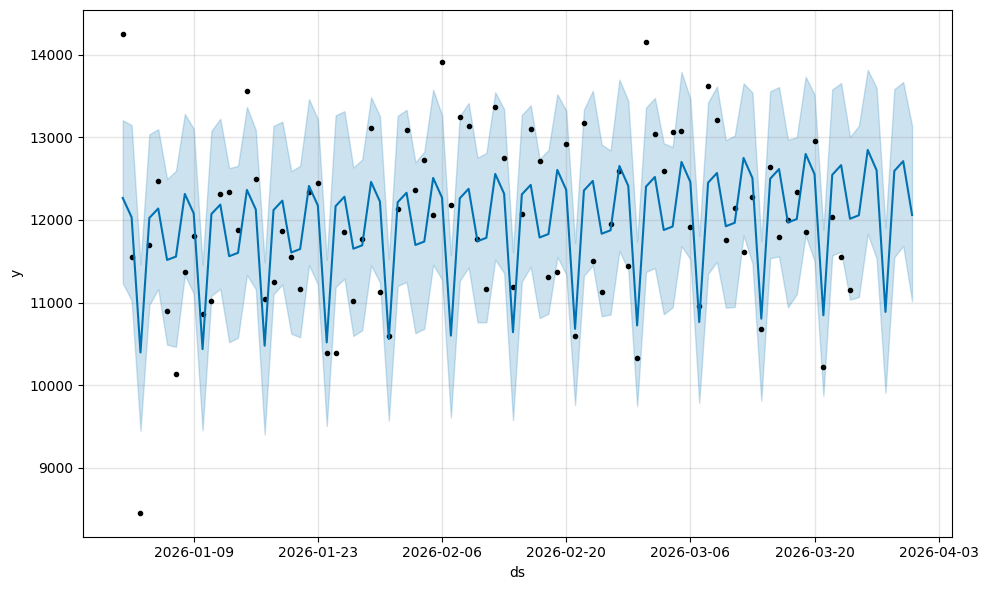

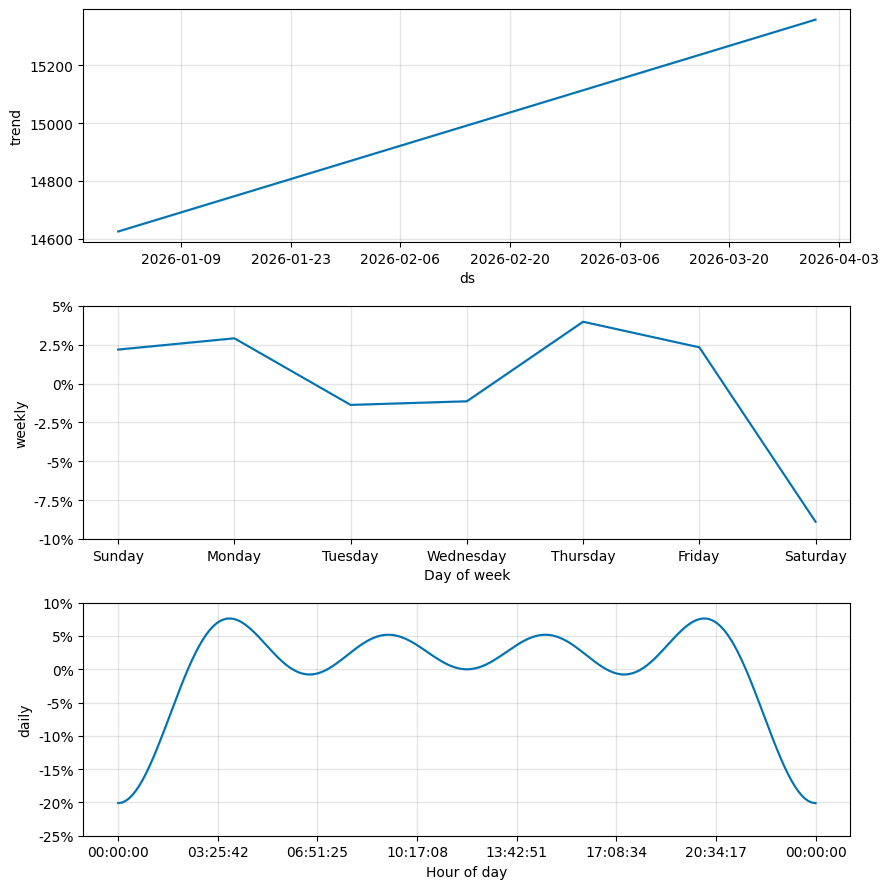

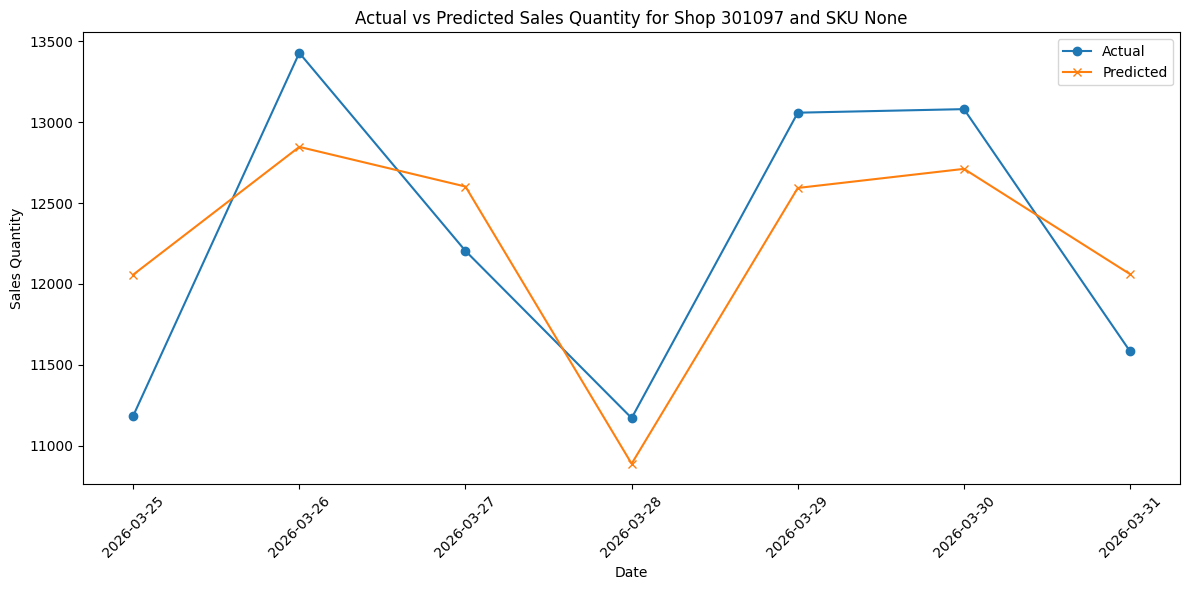

12:13:46 - cmdstanpy - INFO - Chain [1] start processing


Processing 300005 ...


12:13:46 - cmdstanpy - INFO - Chain [1] done processing
12:13:47 - cmdstanpy - INFO - Chain [1] start processing
12:13:47 - cmdstanpy - INFO - Chain [1] done processing
12:13:47 - cmdstanpy - INFO - Chain [1] start processing
12:13:47 - cmdstanpy - INFO - Chain [1] done processing
12:13:47 - cmdstanpy - INFO - Chain [1] start processing
12:13:47 - cmdstanpy - INFO - Chain [1] done processing
12:13:47 - cmdstanpy - INFO - Chain [1] start processing
12:13:47 - cmdstanpy - INFO - Chain [1] done processing
12:13:47 - cmdstanpy - INFO - Chain [1] start processing
12:13:47 - cmdstanpy - INFO - Chain [1] done processing
12:13:47 - cmdstanpy - INFO - Chain [1] start processing
12:13:48 - cmdstanpy - INFO - Chain [1] done processing
12:13:48 - cmdstanpy - INFO - Chain [1] start processing
12:13:48 - cmdstanpy - INFO - Chain [1] done processing
12:13:49 - cmdstanpy - INFO - Chain [1] start processing
12:13:49 - cmdstanpy - INFO - Chain [1] done processing
12:13:49 - cmdstanpy - INFO - Chain [1] 

Best Params: {'changepoint_prior_scale': 0.5, 'seasonality_prior_scale': 1.0, 'seasonality_mode': 'multiplicative'}
Best RMSE: 1004.0041427413441


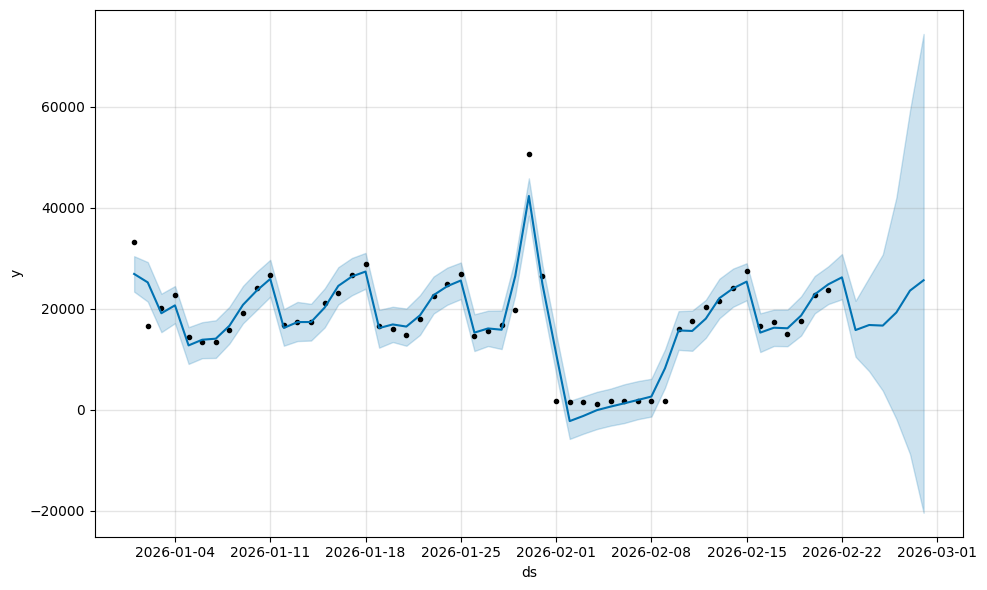

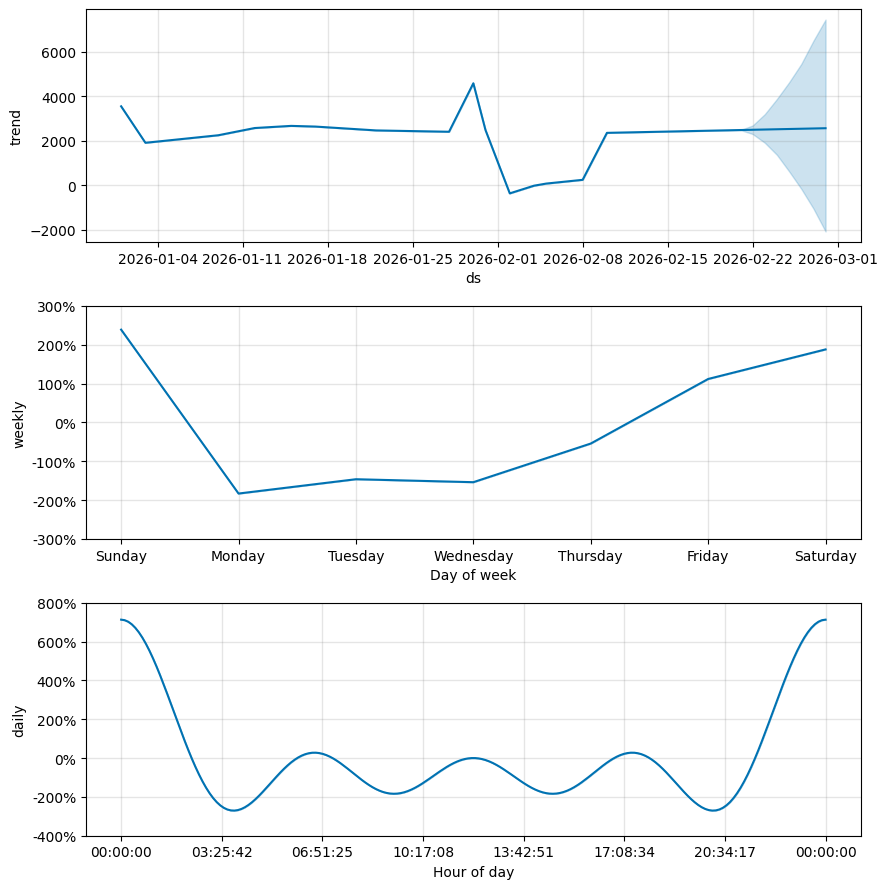

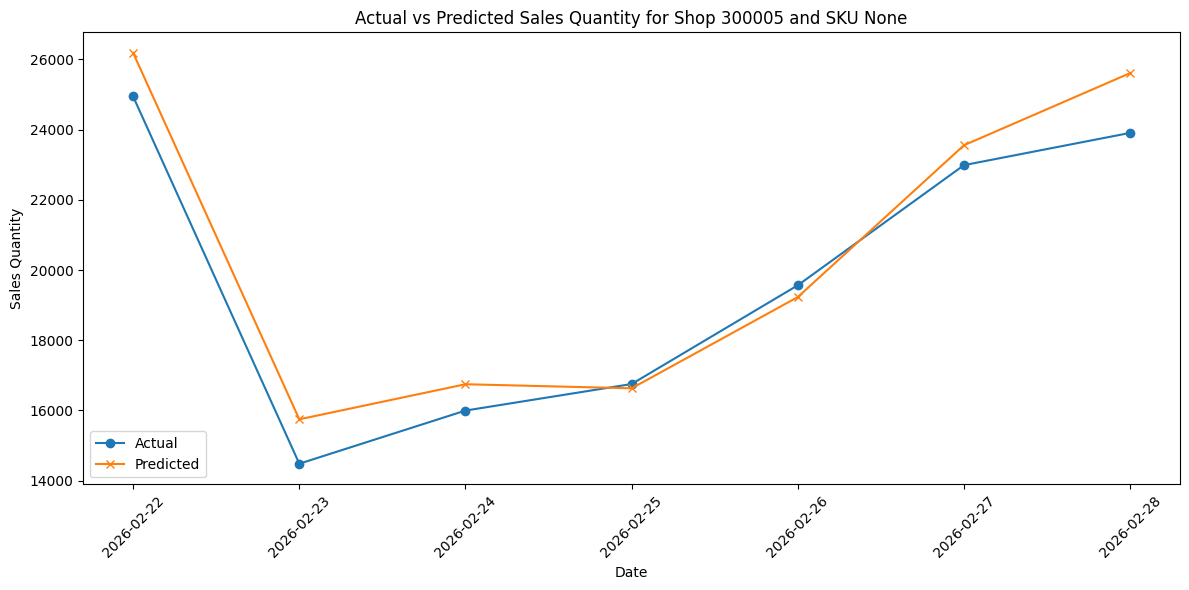

12:13:56 - cmdstanpy - INFO - Chain [1] start processing


Processing 304032 ...


12:13:57 - cmdstanpy - INFO - Chain [1] done processing
12:13:57 - cmdstanpy - INFO - Chain [1] start processing
12:13:57 - cmdstanpy - INFO - Chain [1] done processing
12:13:57 - cmdstanpy - INFO - Chain [1] start processing
12:13:58 - cmdstanpy - INFO - Chain [1] done processing
12:13:58 - cmdstanpy - INFO - Chain [1] start processing
12:13:58 - cmdstanpy - INFO - Chain [1] done processing
12:13:58 - cmdstanpy - INFO - Chain [1] start processing
12:13:58 - cmdstanpy - INFO - Chain [1] done processing
12:13:59 - cmdstanpy - INFO - Chain [1] start processing
12:13:59 - cmdstanpy - INFO - Chain [1] done processing
12:13:59 - cmdstanpy - INFO - Chain [1] start processing
12:14:00 - cmdstanpy - INFO - Chain [1] done processing
12:14:00 - cmdstanpy - INFO - Chain [1] start processing
12:14:01 - cmdstanpy - INFO - Chain [1] done processing
12:14:01 - cmdstanpy - INFO - Chain [1] start processing
12:14:01 - cmdstanpy - INFO - Chain [1] done processing
12:14:01 - cmdstanpy - INFO - Chain [1] 

Best Params: {'changepoint_prior_scale': 0.5, 'seasonality_prior_scale': 10.0, 'seasonality_mode': 'multiplicative'}
Best RMSE: 758.7029356680249


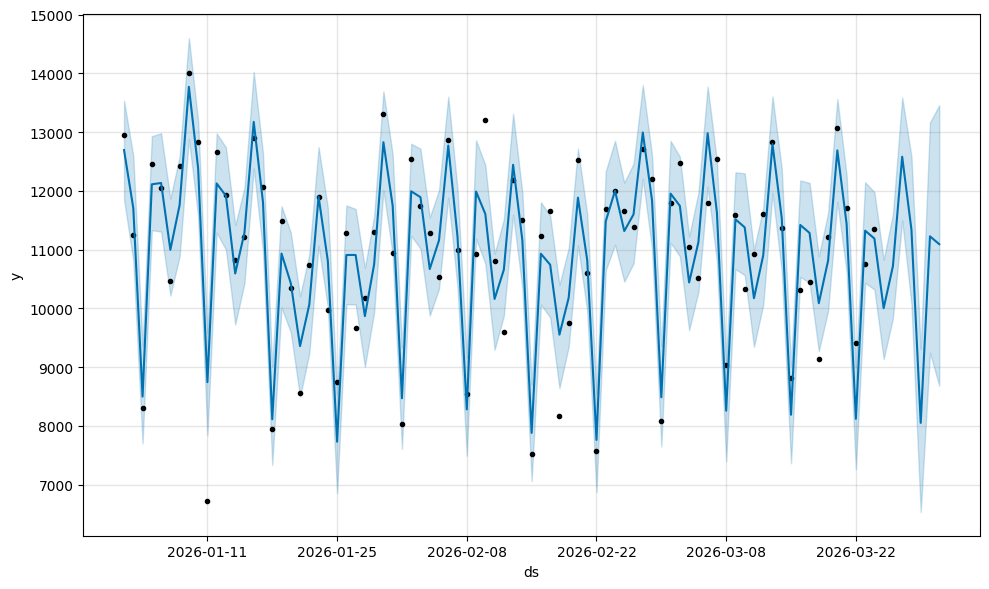

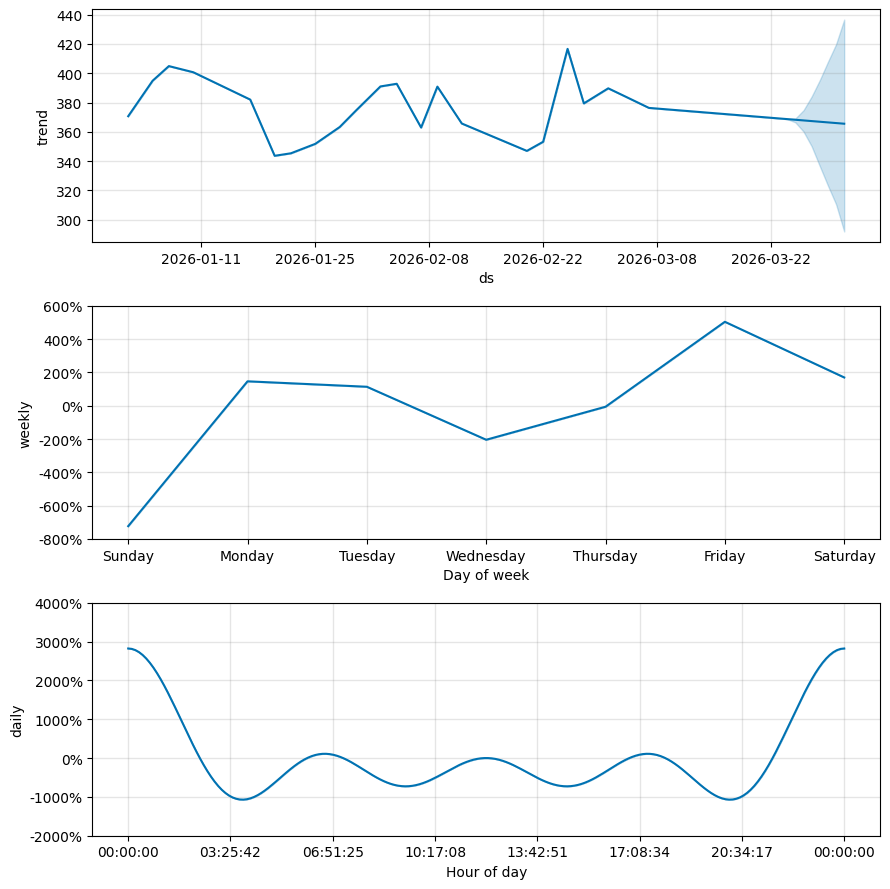

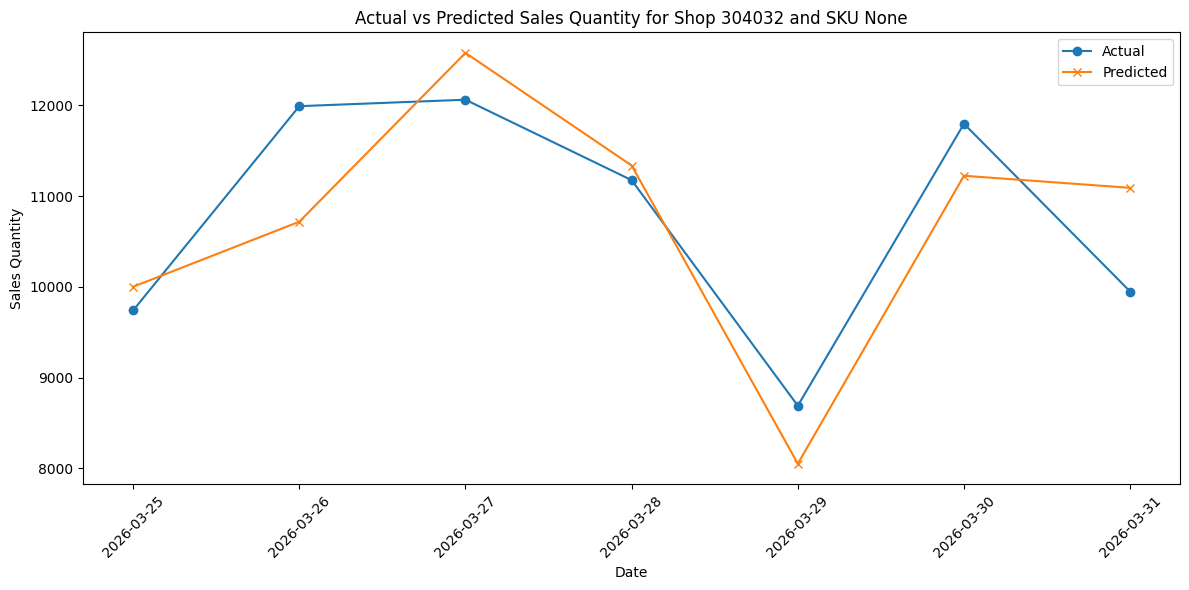

12:14:12 - cmdstanpy - INFO - Chain [1] start processing


Processing 306055 ...


12:14:13 - cmdstanpy - INFO - Chain [1] done processing
12:14:13 - cmdstanpy - INFO - Chain [1] start processing
12:14:13 - cmdstanpy - INFO - Chain [1] done processing
12:14:13 - cmdstanpy - INFO - Chain [1] start processing
12:14:13 - cmdstanpy - INFO - Chain [1] done processing
12:14:14 - cmdstanpy - INFO - Chain [1] start processing
12:14:14 - cmdstanpy - INFO - Chain [1] done processing
12:14:14 - cmdstanpy - INFO - Chain [1] start processing
12:14:14 - cmdstanpy - INFO - Chain [1] done processing
12:14:14 - cmdstanpy - INFO - Chain [1] start processing
12:14:14 - cmdstanpy - INFO - Chain [1] done processing
12:14:14 - cmdstanpy - INFO - Chain [1] start processing
12:14:15 - cmdstanpy - INFO - Chain [1] done processing
12:14:15 - cmdstanpy - INFO - Chain [1] start processing
12:14:15 - cmdstanpy - INFO - Chain [1] done processing
12:14:16 - cmdstanpy - INFO - Chain [1] start processing
12:14:16 - cmdstanpy - INFO - Chain [1] done processing
12:14:16 - cmdstanpy - INFO - Chain [1] 

Best Params: {'changepoint_prior_scale': 0.1, 'seasonality_prior_scale': 5.0, 'seasonality_mode': 'additive'}
Best RMSE: 1092.9385517800872


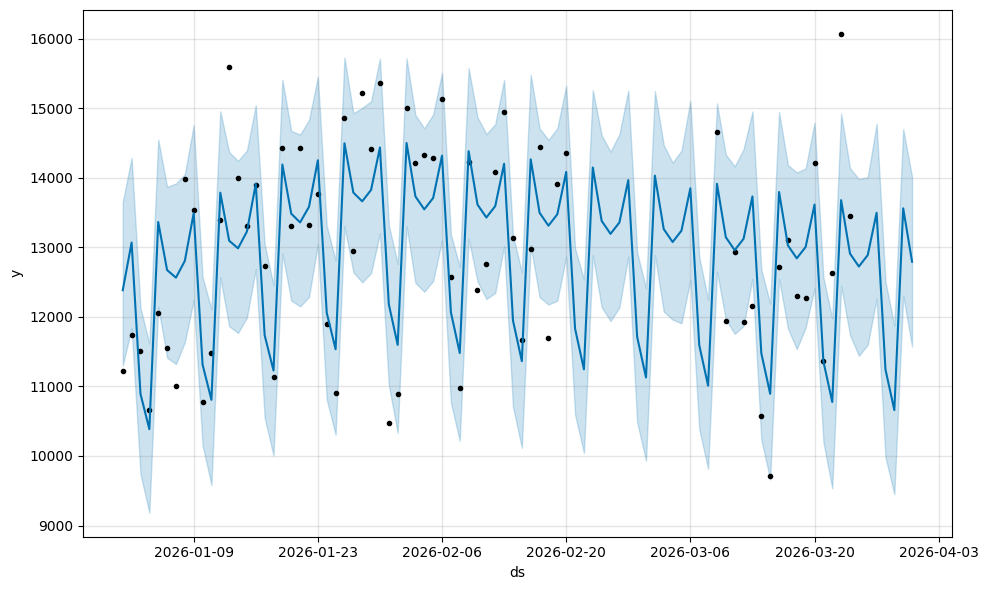

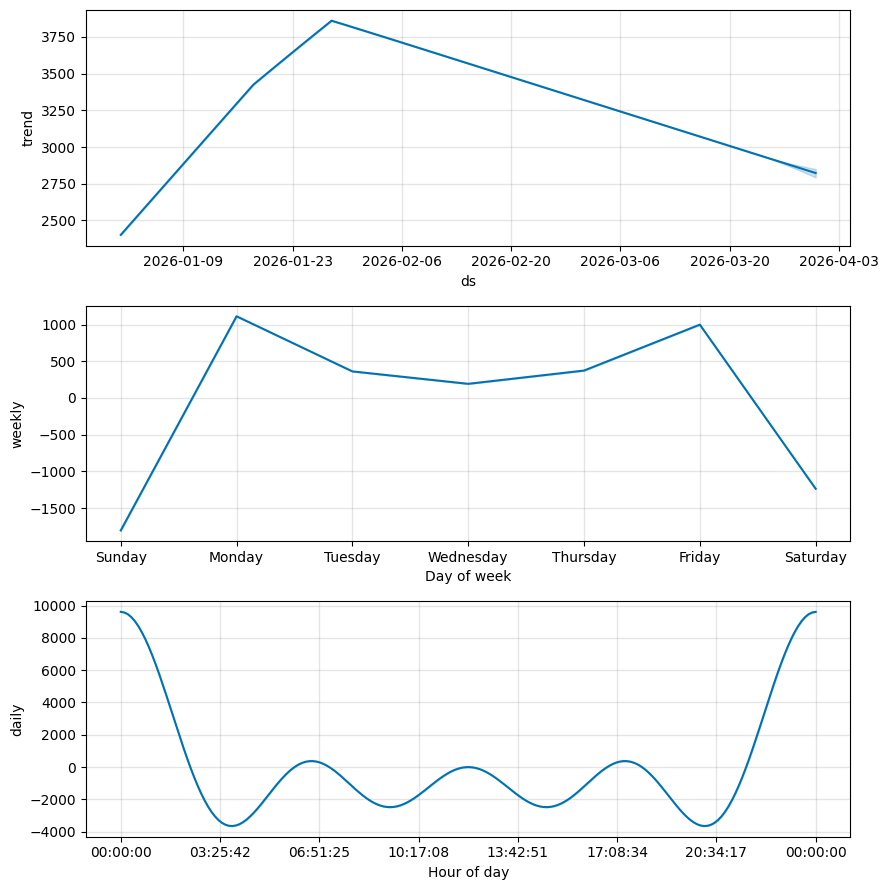

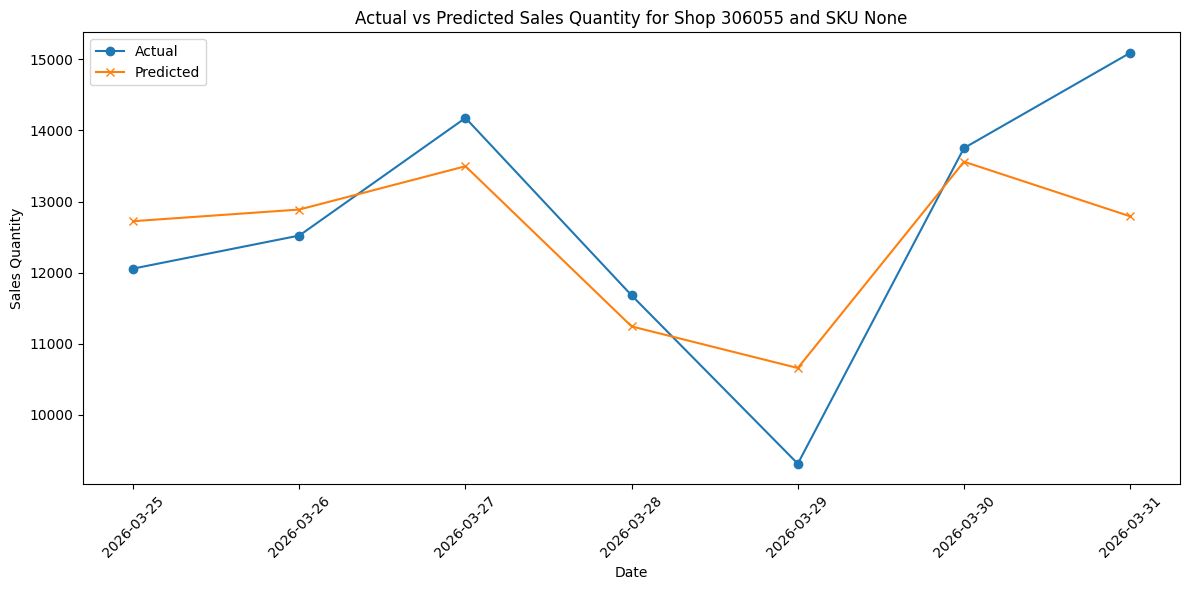

12:14:26 - cmdstanpy - INFO - Chain [1] start processing


Processing 302198 ...


12:14:26 - cmdstanpy - INFO - Chain [1] done processing
12:14:26 - cmdstanpy - INFO - Chain [1] start processing
12:14:26 - cmdstanpy - INFO - Chain [1] done processing
12:14:26 - cmdstanpy - INFO - Chain [1] start processing
12:14:27 - cmdstanpy - INFO - Chain [1] done processing
12:14:27 - cmdstanpy - INFO - Chain [1] start processing
12:14:27 - cmdstanpy - INFO - Chain [1] done processing
12:14:27 - cmdstanpy - INFO - Chain [1] start processing
12:14:27 - cmdstanpy - INFO - Chain [1] done processing
12:14:27 - cmdstanpy - INFO - Chain [1] start processing
12:14:28 - cmdstanpy - INFO - Chain [1] done processing
12:14:28 - cmdstanpy - INFO - Chain [1] start processing
12:14:28 - cmdstanpy - INFO - Chain [1] done processing
12:14:29 - cmdstanpy - INFO - Chain [1] start processing
12:14:29 - cmdstanpy - INFO - Chain [1] done processing
12:14:29 - cmdstanpy - INFO - Chain [1] start processing
12:14:30 - cmdstanpy - INFO - Chain [1] done processing
12:14:30 - cmdstanpy - INFO - Chain [1] 

Best Params: {'changepoint_prior_scale': 0.01, 'seasonality_prior_scale': 5.0, 'seasonality_mode': 'multiplicative'}
Best RMSE: 1399.6091422596744


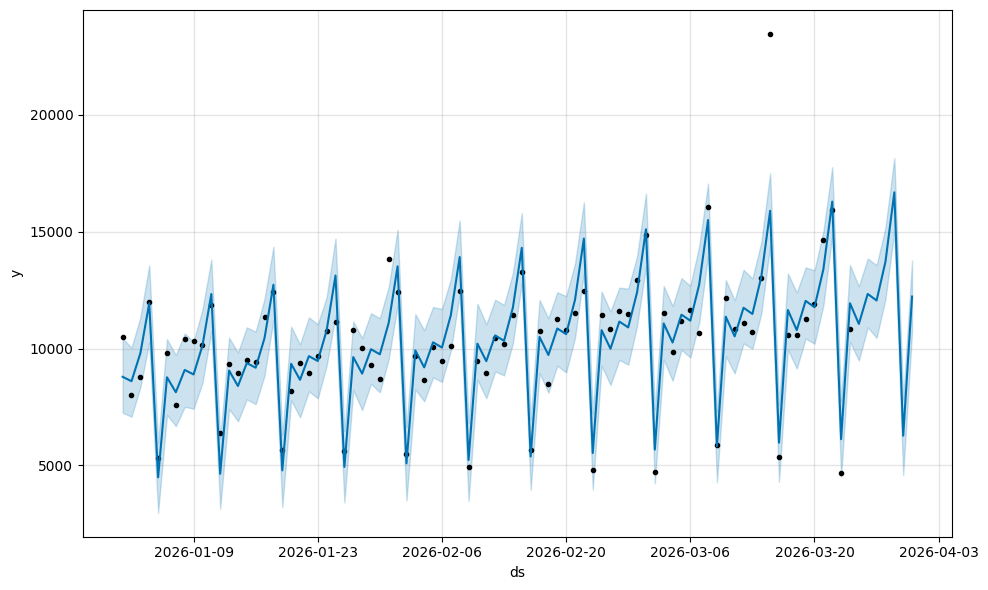

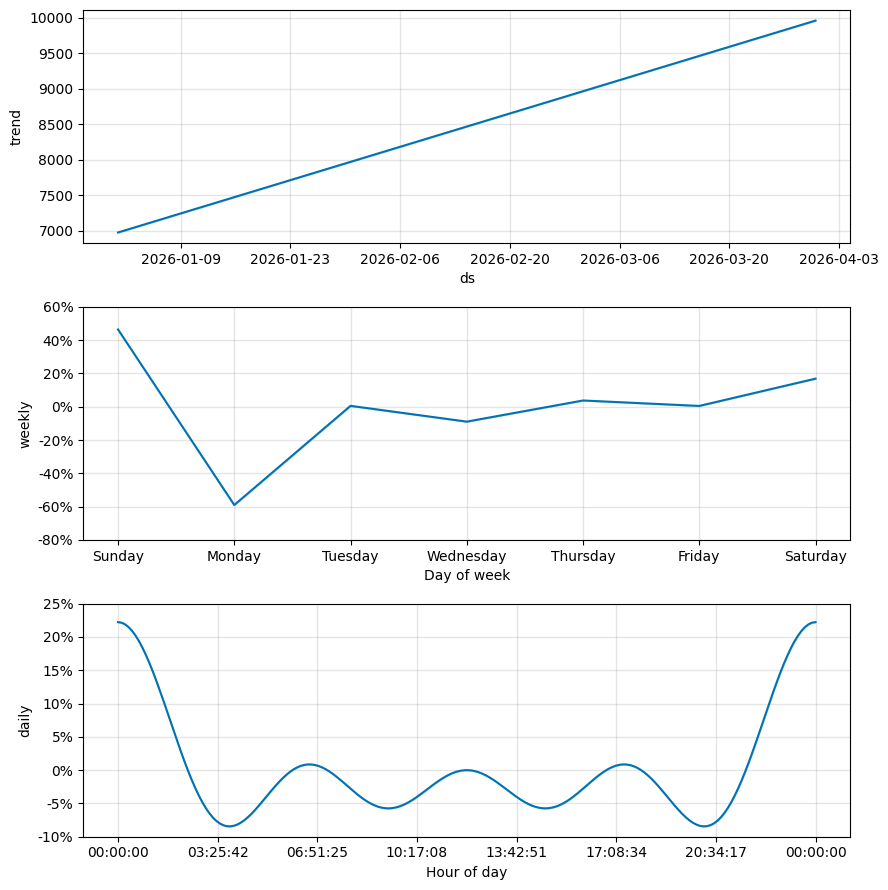

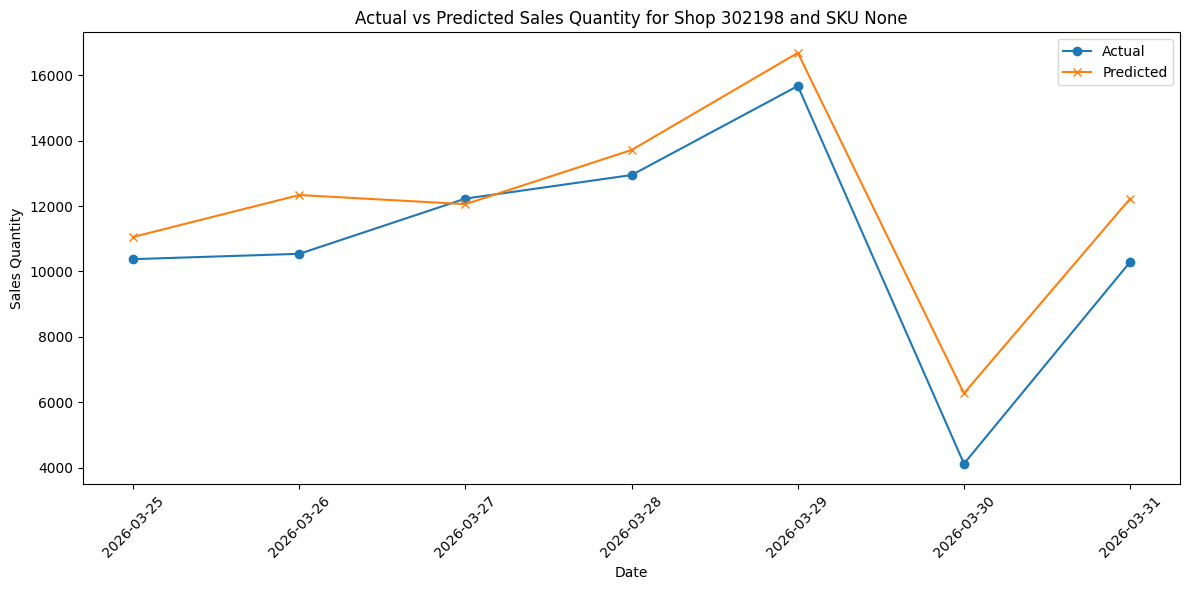

In [26]:
result = train(top_n_customers, all_params)

12:17:09 - cmdstanpy - INFO - Chain [1] start processing


Processing 301097 ...


12:17:09 - cmdstanpy - INFO - Chain [1] done processing
12:17:09 - cmdstanpy - INFO - Chain [1] start processing
12:17:10 - cmdstanpy - INFO - Chain [1] done processing
12:17:10 - cmdstanpy - INFO - Chain [1] start processing
12:17:10 - cmdstanpy - INFO - Chain [1] done processing
12:17:10 - cmdstanpy - INFO - Chain [1] start processing
12:17:10 - cmdstanpy - INFO - Chain [1] done processing
12:17:11 - cmdstanpy - INFO - Chain [1] start processing
12:17:11 - cmdstanpy - INFO - Chain [1] done processing
12:17:11 - cmdstanpy - INFO - Chain [1] start processing
12:17:11 - cmdstanpy - INFO - Chain [1] done processing
12:17:11 - cmdstanpy - INFO - Chain [1] start processing
12:17:12 - cmdstanpy - INFO - Chain [1] done processing
12:17:12 - cmdstanpy - INFO - Chain [1] start processing
12:17:13 - cmdstanpy - INFO - Chain [1] done processing
12:17:13 - cmdstanpy - INFO - Chain [1] start processing
12:17:13 - cmdstanpy - INFO - Chain [1] done processing
12:17:14 - cmdstanpy - INFO - Chain [1] 

Best Params: {'changepoint_prior_scale': 0.01, 'seasonality_prior_scale': 1.0, 'seasonality_mode': 'multiplicative'}
Best RMSE: 523.9431024570704


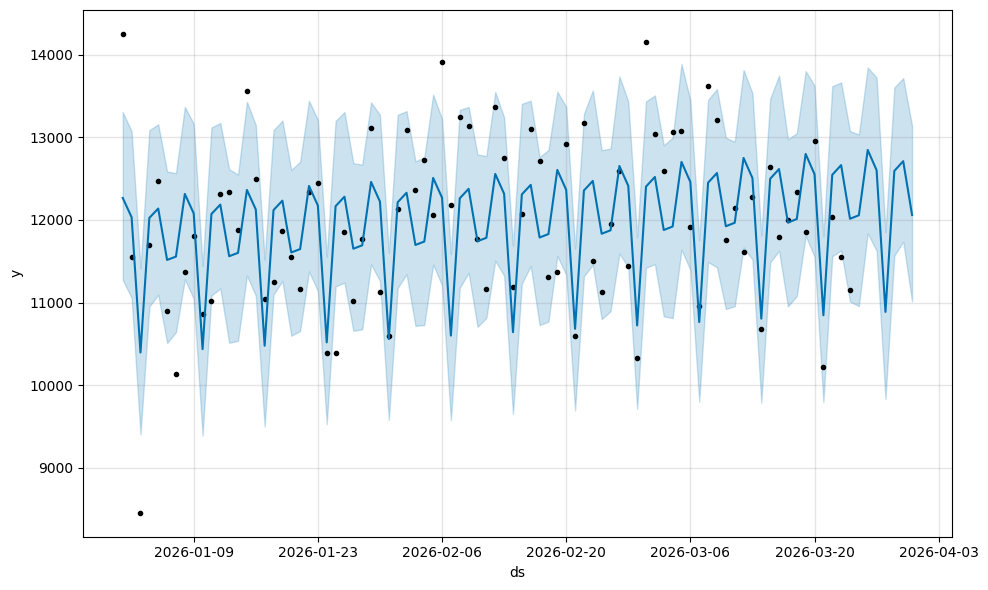

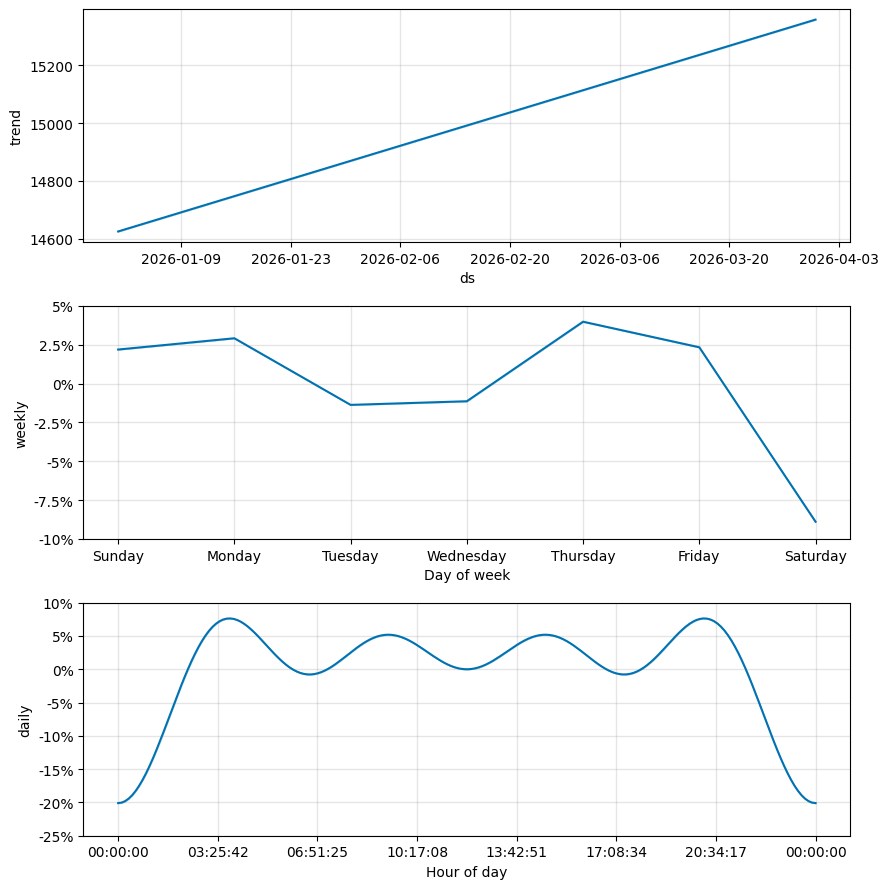

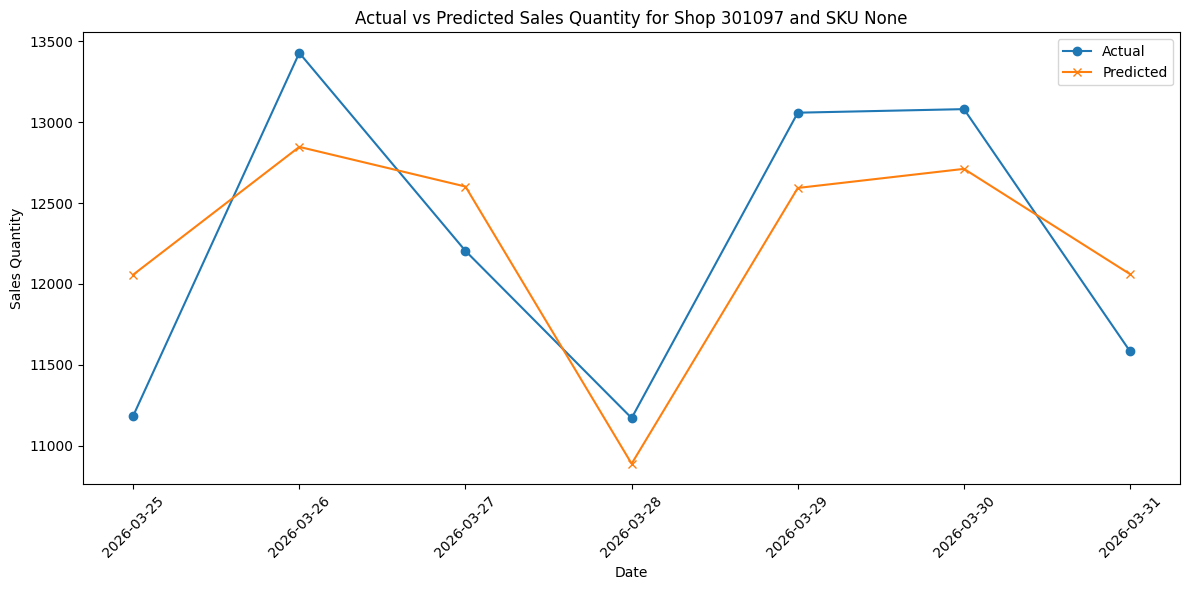

12:17:25 - cmdstanpy - INFO - Chain [1] start processing


Processing 300005 ...


12:17:25 - cmdstanpy - INFO - Chain [1] done processing
12:17:25 - cmdstanpy - INFO - Chain [1] start processing
12:17:25 - cmdstanpy - INFO - Chain [1] done processing
12:17:25 - cmdstanpy - INFO - Chain [1] start processing
12:17:25 - cmdstanpy - INFO - Chain [1] done processing
12:17:25 - cmdstanpy - INFO - Chain [1] start processing
12:17:25 - cmdstanpy - INFO - Chain [1] done processing
12:17:25 - cmdstanpy - INFO - Chain [1] start processing
12:17:26 - cmdstanpy - INFO - Chain [1] done processing
12:17:26 - cmdstanpy - INFO - Chain [1] start processing
12:17:26 - cmdstanpy - INFO - Chain [1] done processing
12:17:26 - cmdstanpy - INFO - Chain [1] start processing
12:17:26 - cmdstanpy - INFO - Chain [1] done processing
12:17:26 - cmdstanpy - INFO - Chain [1] start processing
12:17:26 - cmdstanpy - INFO - Chain [1] done processing
12:17:27 - cmdstanpy - INFO - Chain [1] start processing
12:17:27 - cmdstanpy - INFO - Chain [1] done processing
12:17:27 - cmdstanpy - INFO - Chain [1] 

Best Params: {'changepoint_prior_scale': 0.5, 'seasonality_prior_scale': 1.0, 'seasonality_mode': 'multiplicative'}
Best RMSE: 1004.0041427413441


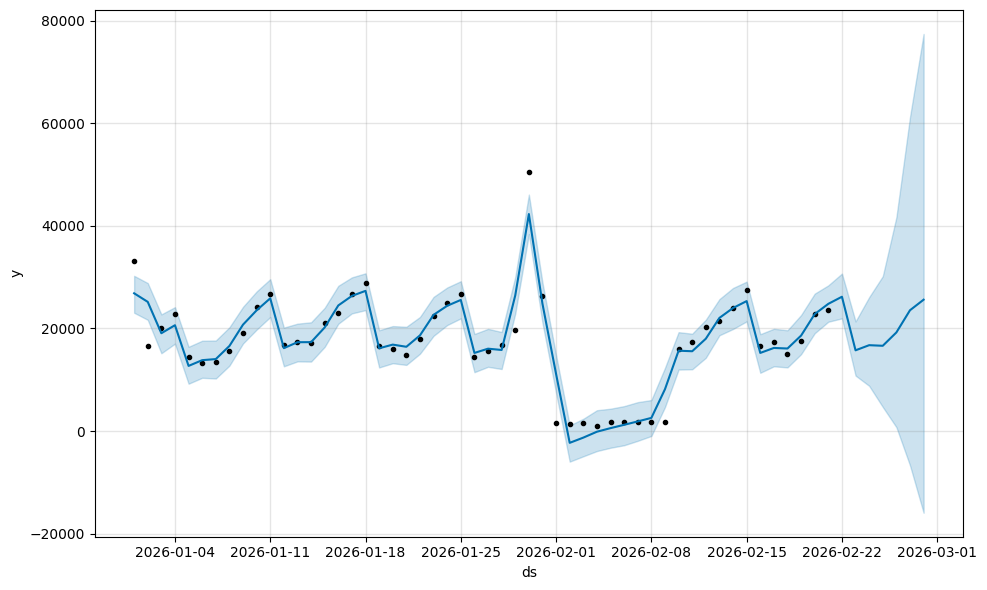

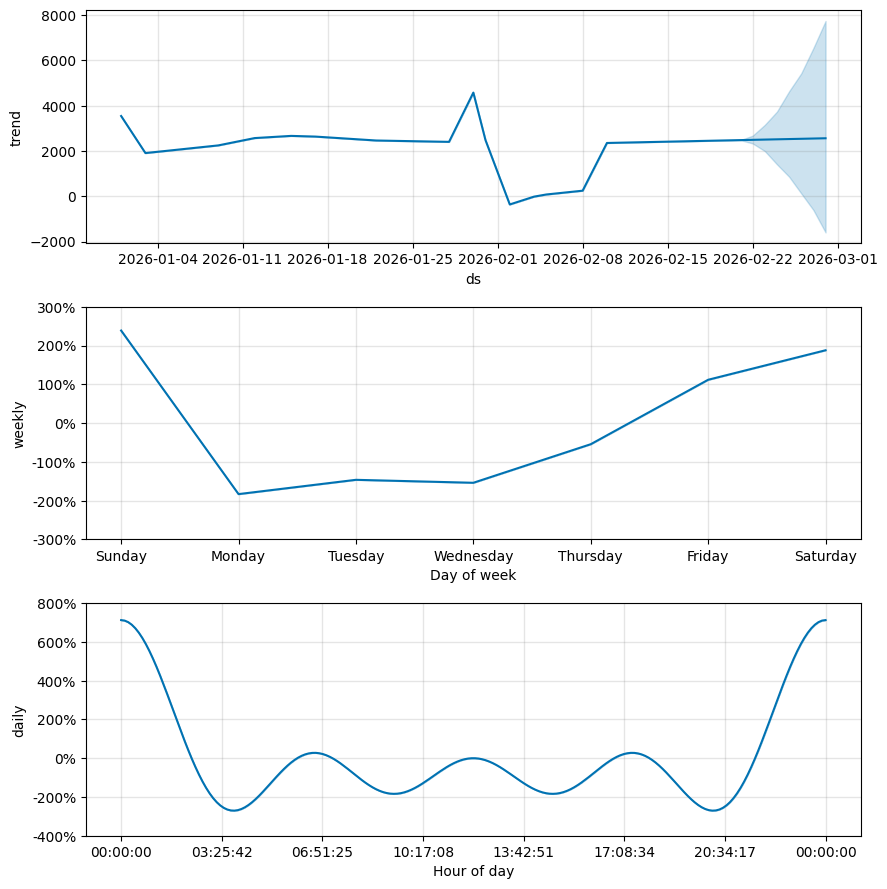

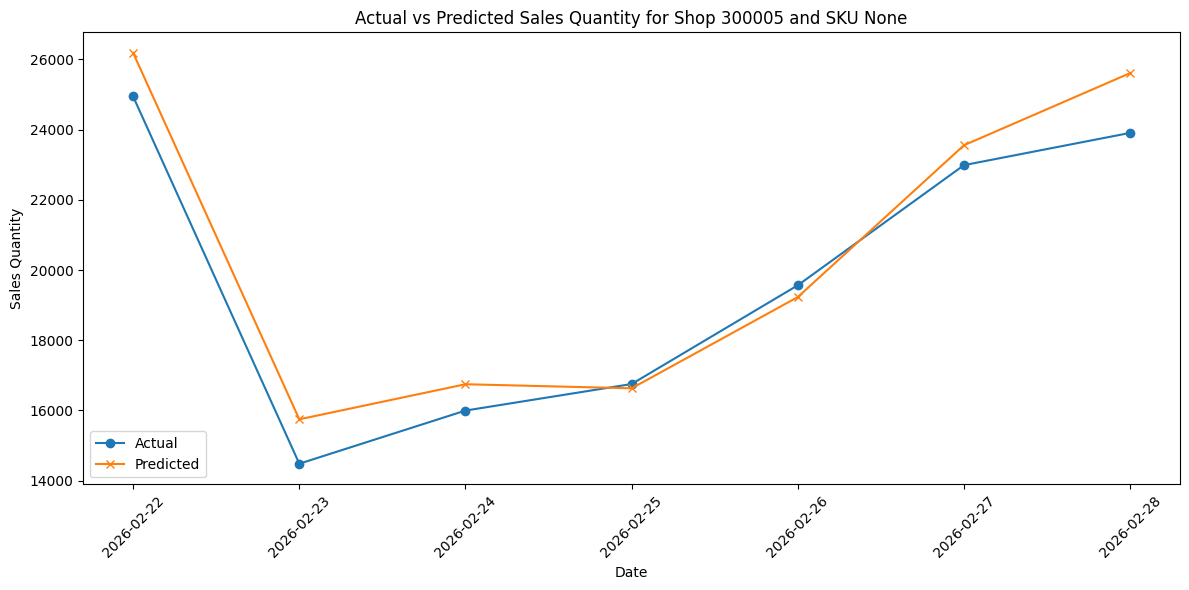

12:17:32 - cmdstanpy - INFO - Chain [1] start processing


Processing 304032 ...


12:17:32 - cmdstanpy - INFO - Chain [1] done processing
12:17:32 - cmdstanpy - INFO - Chain [1] start processing
12:17:33 - cmdstanpy - INFO - Chain [1] done processing
12:17:33 - cmdstanpy - INFO - Chain [1] start processing
12:17:33 - cmdstanpy - INFO - Chain [1] done processing
12:17:33 - cmdstanpy - INFO - Chain [1] start processing
12:17:33 - cmdstanpy - INFO - Chain [1] done processing
12:17:33 - cmdstanpy - INFO - Chain [1] start processing
12:17:33 - cmdstanpy - INFO - Chain [1] done processing
12:17:33 - cmdstanpy - INFO - Chain [1] start processing
12:17:34 - cmdstanpy - INFO - Chain [1] done processing
12:17:34 - cmdstanpy - INFO - Chain [1] start processing
12:17:34 - cmdstanpy - INFO - Chain [1] done processing
12:17:34 - cmdstanpy - INFO - Chain [1] start processing
12:17:35 - cmdstanpy - INFO - Chain [1] done processing
12:17:35 - cmdstanpy - INFO - Chain [1] start processing
12:17:35 - cmdstanpy - INFO - Chain [1] done processing
12:17:35 - cmdstanpy - INFO - Chain [1] 

Best Params: {'changepoint_prior_scale': 0.5, 'seasonality_prior_scale': 10.0, 'seasonality_mode': 'multiplicative'}
Best RMSE: 758.7029356680249


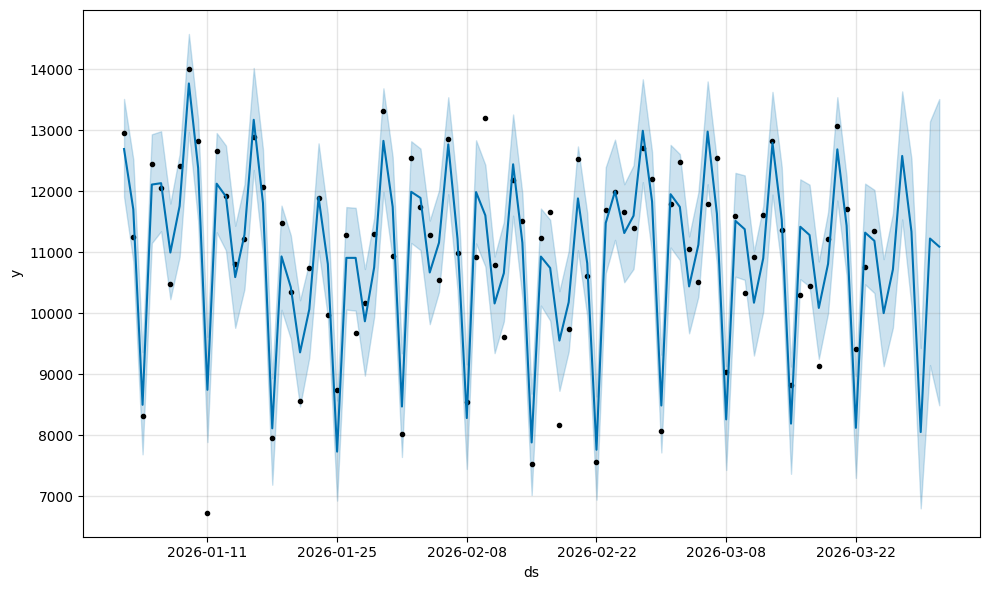

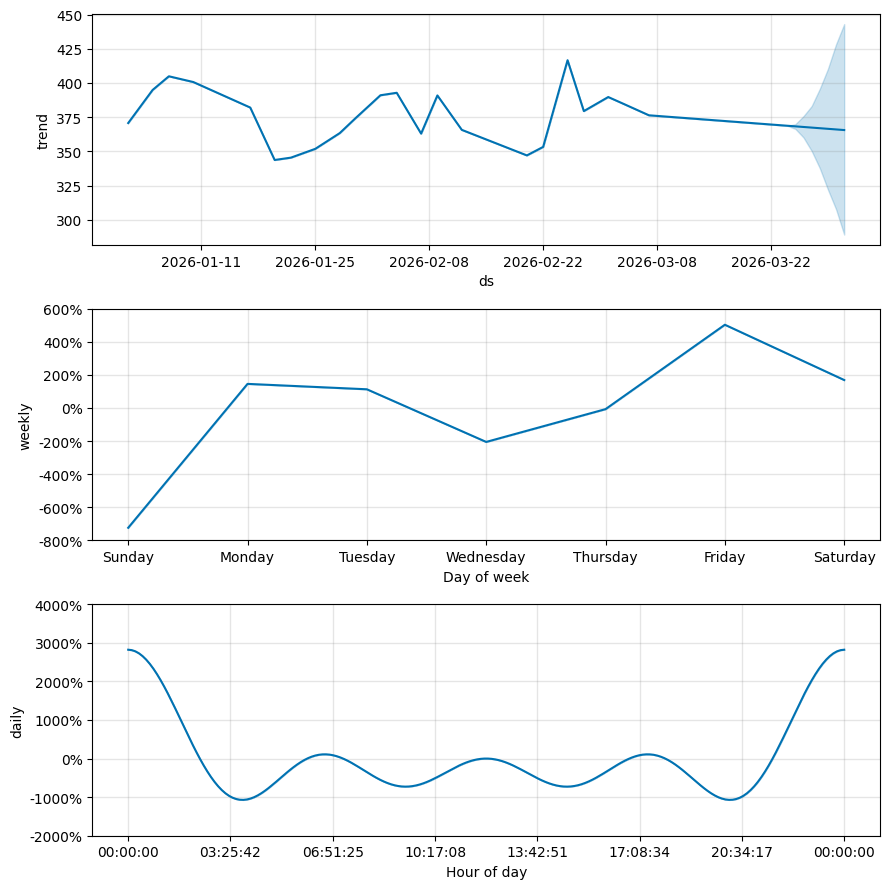

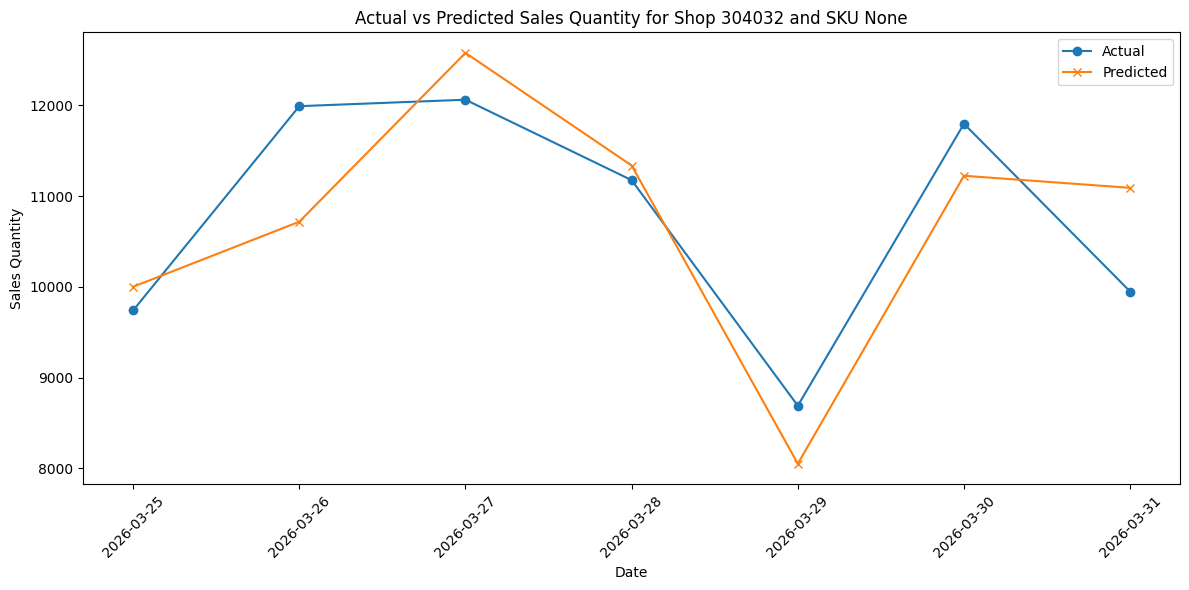

12:17:47 - cmdstanpy - INFO - Chain [1] start processing


Processing 306055 ...


12:17:47 - cmdstanpy - INFO - Chain [1] done processing
12:17:47 - cmdstanpy - INFO - Chain [1] start processing
12:17:47 - cmdstanpy - INFO - Chain [1] done processing
12:17:48 - cmdstanpy - INFO - Chain [1] start processing
12:17:48 - cmdstanpy - INFO - Chain [1] done processing
12:17:48 - cmdstanpy - INFO - Chain [1] start processing
12:17:48 - cmdstanpy - INFO - Chain [1] done processing
12:17:49 - cmdstanpy - INFO - Chain [1] start processing
12:17:49 - cmdstanpy - INFO - Chain [1] done processing
12:17:49 - cmdstanpy - INFO - Chain [1] start processing
12:17:49 - cmdstanpy - INFO - Chain [1] done processing
12:17:49 - cmdstanpy - INFO - Chain [1] start processing
12:17:49 - cmdstanpy - INFO - Chain [1] done processing
12:17:50 - cmdstanpy - INFO - Chain [1] start processing
12:17:50 - cmdstanpy - INFO - Chain [1] done processing
12:17:50 - cmdstanpy - INFO - Chain [1] start processing
12:17:51 - cmdstanpy - INFO - Chain [1] done processing
12:17:51 - cmdstanpy - INFO - Chain [1] 

Best Params: {'changepoint_prior_scale': 0.1, 'seasonality_prior_scale': 5.0, 'seasonality_mode': 'additive'}
Best RMSE: 1092.9385517800872


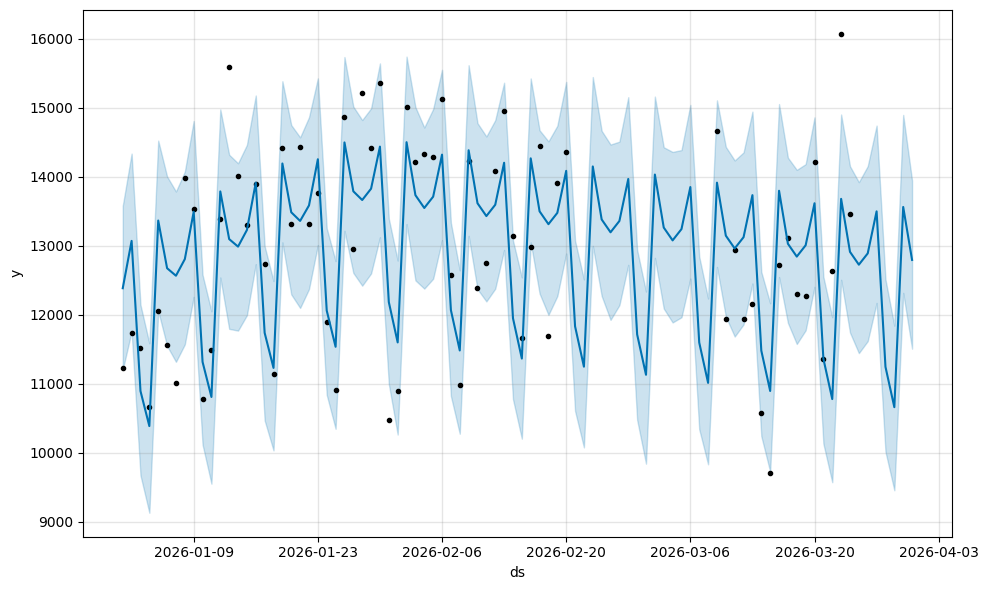

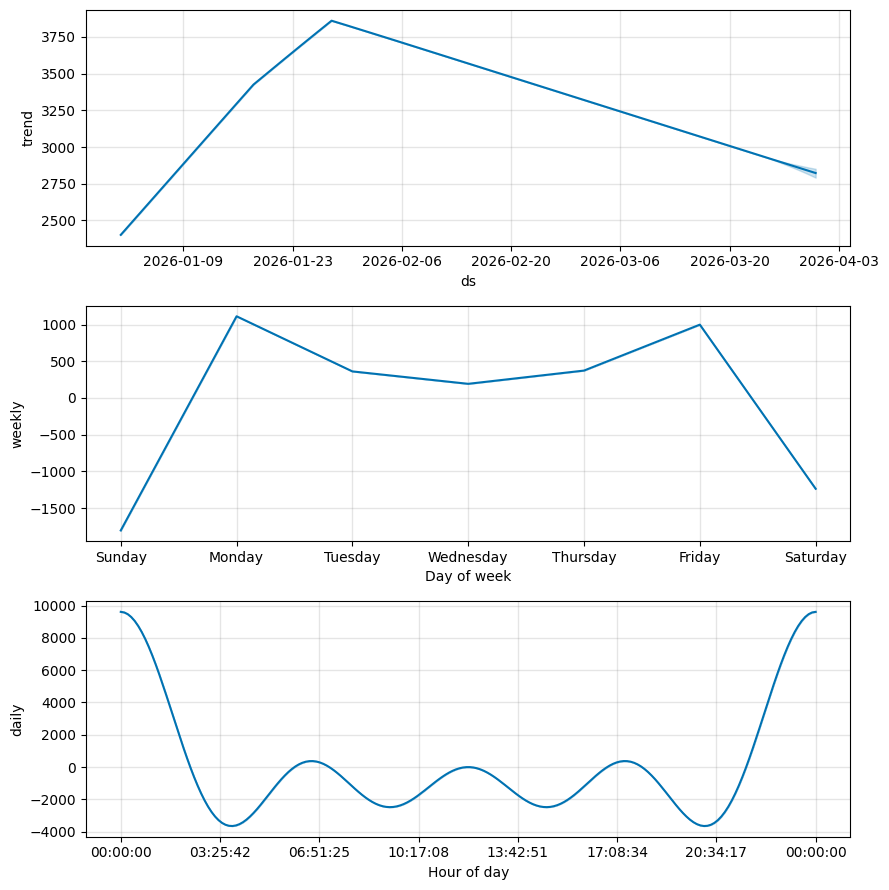

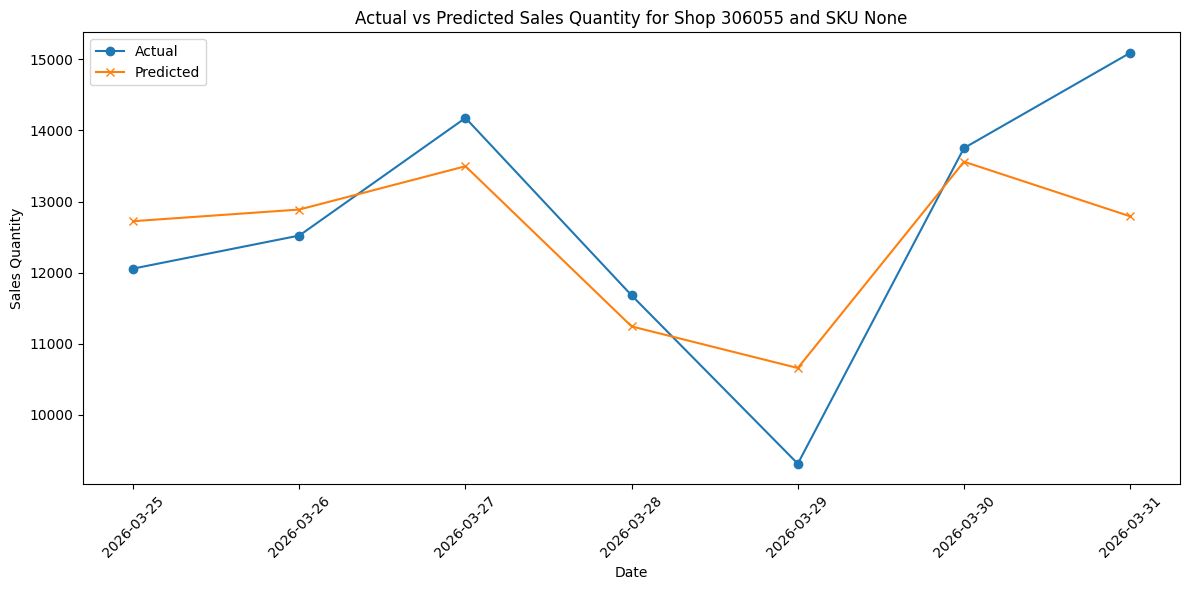

12:18:00 - cmdstanpy - INFO - Chain [1] start processing


Processing 302198 ...


12:18:00 - cmdstanpy - INFO - Chain [1] done processing
12:18:00 - cmdstanpy - INFO - Chain [1] start processing
12:18:00 - cmdstanpy - INFO - Chain [1] done processing
12:18:00 - cmdstanpy - INFO - Chain [1] start processing
12:18:00 - cmdstanpy - INFO - Chain [1] done processing
12:18:01 - cmdstanpy - INFO - Chain [1] start processing
12:18:01 - cmdstanpy - INFO - Chain [1] done processing
12:18:01 - cmdstanpy - INFO - Chain [1] start processing
12:18:01 - cmdstanpy - INFO - Chain [1] done processing
12:18:01 - cmdstanpy - INFO - Chain [1] start processing
12:18:01 - cmdstanpy - INFO - Chain [1] done processing
12:18:02 - cmdstanpy - INFO - Chain [1] start processing
12:18:02 - cmdstanpy - INFO - Chain [1] done processing
12:18:02 - cmdstanpy - INFO - Chain [1] start processing
12:18:03 - cmdstanpy - INFO - Chain [1] done processing
12:18:03 - cmdstanpy - INFO - Chain [1] start processing
12:18:03 - cmdstanpy - INFO - Chain [1] done processing
12:18:03 - cmdstanpy - INFO - Chain [1] 

Best Params: {'changepoint_prior_scale': 0.01, 'seasonality_prior_scale': 5.0, 'seasonality_mode': 'multiplicative'}
Best RMSE: 1399.6091422596744


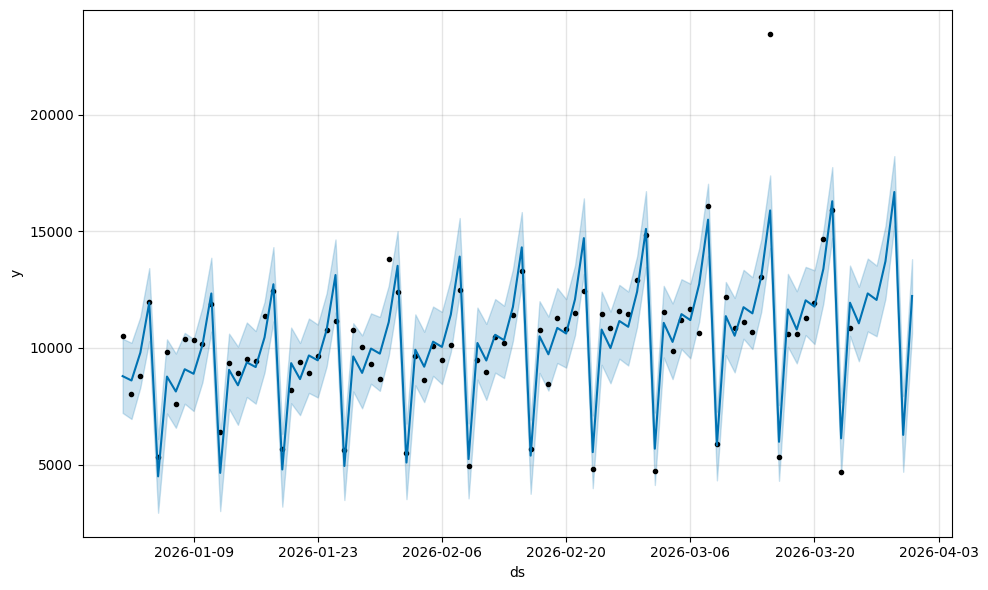

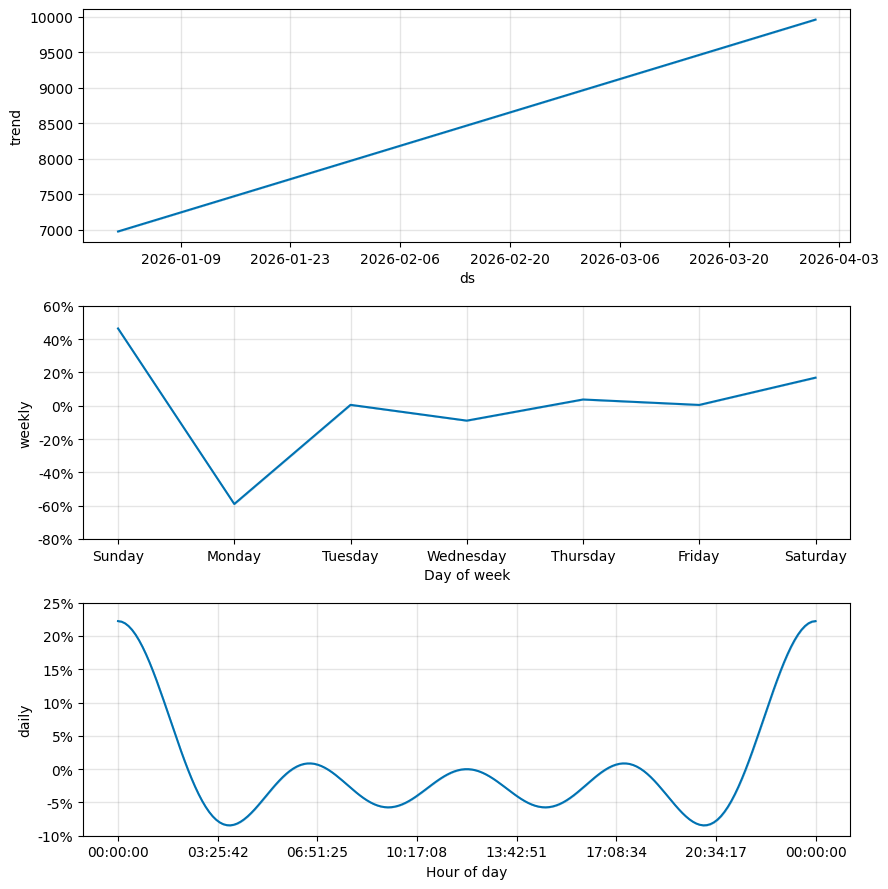

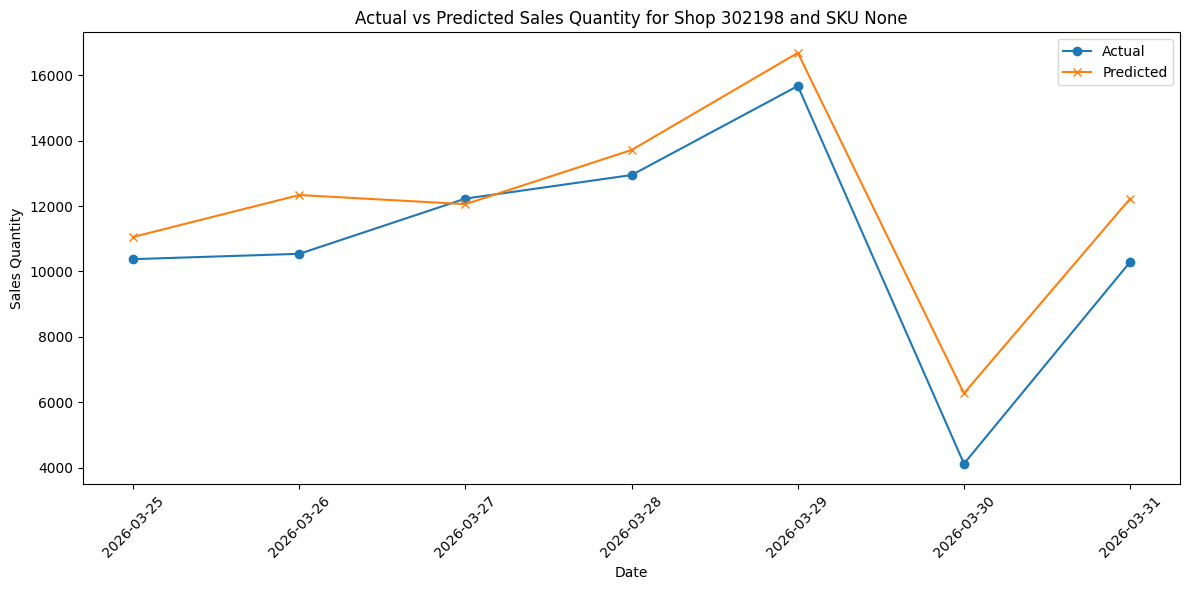

In [32]:
results = train(top_n_customers, all_params, add_holidays=True)

### Prediction on Sell In Data

In [25]:
df_path = "../../../../data/France/processed_data/sell_in_merged.csv"
df = pd.read_csv(df_path, low_memory=False)
df["date"] = pd.to_datetime(df["date"])

df = df[df["sku_code"] != 99999]

In [26]:
df.tail()

,date,outlet_sf_id,sku_code,sku_code.1,sku_sf_id,sku_sf_id.1,record_type,sales_quantity,sales_amount,sku_sf_id.2,sku_sf_id.3,trade_sku_sf_id,sku_record,outlet_salesforce_id,customer_code,customer_name,status,channel_name,latitude,longitude,route,route_name,area,region,sku_code.2,sku_code.3,sku_name,brand_variant,brand_variant_code,brand_name,brand_code,category,invoice_code,sec
122301,2026-03-30,0011t000011b23yAAA,3010,NaN,NaN,a0U1t000002PXkTEAW,Trade SKU,200,1,NaN,a0U1t000002PXkTEAW,NaN,NaN,0011t000011b23yAAA,308158,308158 - BALTO (LE),Active,Independent,48.863350,2.369310,a0D1t000005iLBVEA2,France_FRDiv_Reg1_AREA_A_SECTEUR_A_08,FR_France_FRDiv_Reg1_AREA_A,FR_France_FRDiv_Reg1,3010,NaN,NaN,NaN,NaN,NaN,NaN,NaN,202603300155,C
122302,2026-03-30,0011t000011b23yAAA,1201,NaN,NaN,a0U1t000002PXjoEAG,Trade SKU,200,1,NaN,a0U1t000002PXjoEAG,NaN,NaN,0011t000011b23yAAA,308158,308158 - BALTO (LE),Active,Independent,48.863350,2.369310,a0D1t000005iLBVEA2,France_FRDiv_Reg1_AREA_A_SECTEUR_A_08,FR_France_FRDiv_Reg1_AREA_A,FR_France_FRDiv_Reg1,1201,NaN,NaN,NaN,NaN,NaN,NaN,NaN,202603300156,C
122303,2026-03-30,0011t000011b23yAAA,125,NaN,NaN,a0U1t000002PXloEAG,Trade SKU,400,2,NaN,a0U1t000002PXloEAG,NaN,NaN,0011t000011b23yAAA,308158,308158 - BALTO (LE),Active,Independent,48.863350,2.369310,a0D1t000005iLBVEA2,France_FRDiv_Reg1_AREA_A_SECTEUR_A_08,FR_France_FRDiv_Reg1_AREA_A,FR_France_FRDiv_Reg1,125,NaN,NaN,NaN,NaN,NaN,NaN,NaN,202603300157,B
122305,2026-03-30,0011t000011b9TcAAI,6414,NaN,NaN,a0U1t000002PXnYEAW,Trade SKU,400,2,NaN,a0U1t000002PXnYEAW,NaN,NaN,0011t000011b9TcAAI,303106,303106 - BOYARD (TABAC LE),Active,COCO,48.880270,2.292310,a0D1t000005iLAnEAM,France_FRDiv_Reg1_AREA_A_SECTEUR_A_06,FR_France_FRDiv_Reg1_AREA_A,FR_France_FRDiv_Reg1,6414,NaN,NaN,NaN,NaN,NaN,NaN,NaN,202603300159,B
122306,2026-03-30,0011t000011b1s6AAA,88263,NaN,NaN,a0UJz00000S9kMrMAJ,Trade SKU,5,1,NaN,a0UJz00000S9kMrMAJ,NaN,NaN,0011t000011b1s6AAA,309125,309125 - SAINT CLAUDE (LE),Active,COCO,48.872723,2.312465,a0D1t000005iLAGEA2,France_FRDiv_Reg1_AREA_A_SECTEUR_A_01,FR_France_FRDiv_Reg1_AREA_A,FR_France_FRDiv_Reg1,88263,NaN,NaN,NaN,NaN,NaN,NaN,NaN,202603300160,C


In [33]:
top_n_customers_sell_in = top_n_customer_sales(df, n=5)

In [36]:
train(top_n_customers_sell_in, all_params)

15:02:46 - cmdstanpy - INFO - Chain [1] start processing
15:02:46 - cmdstanpy - INFO - Chain [1] done processing


Processing 302198 ...


15:02:46 - cmdstanpy - INFO - Chain [1] start processing
15:02:46 - cmdstanpy - INFO - Chain [1] done processing


Skipping params {'changepoint_prior_scale': 0.01, 'seasonality_prior_scale': 1.0, 'seasonality_mode': 'additive'} due to error??


15:02:47 - cmdstanpy - INFO - Chain [1] start processing
15:02:47 - cmdstanpy - INFO - Chain [1] done processing


...

15:02:49 - cmdstanpy - INFO - Chain [1] done processing
15:02:49 - cmdstanpy - INFO - Chain [1] start processing
15:02:49 - cmdstanpy - INFO - Chain [1] done processing


Skipping params {'changepoint_prior_scale': 0.5, 'seasonality_prior_scale': 5.0, 'seasonality_mode': 'additive'} due to error??
Skipping params {'changepoint_prior_scale': 0.5, 'seasonality_prior_scale': 5.0, 'seasonality_mode': 'multiplicative'} due to error??


15:02:49 - cmdstanpy - INFO - Chain [1] start processing
15:02:49 - cmdstanpy - INFO - Chain [1] done processing
15:02:49 - cmdstanpy - INFO - Chain [1] start processing
15:02:49 - cmdstanpy - INFO - Chain [1] done processing


Skipping params {'changepoint_prior_scale': 0.5, 'seasonality_prior_scale': 10.0, 'seasonality_mode': 'additive'} due to error??
Skipping params {'changepoint_prior_scale': 0.5, 'seasonality_prior_scale': 10.0, 'seasonality_mode': 'multiplicative'} due to error??
Best Params: None
Best RMSE: inf


AttributeError: 'NoneType' object has no attribute 'plot'